# Battery Data Cleaning and Analysis (Python)

This notebook demonstrates a complete workflow for:
- Loading battery test data
- Cleaning missing values
- Computing electrical power
- Visualizing results

Tools used: Python, NumPy, Pandas, Matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
time = np.arange(0, 6)
voltage = np.array([3.2, 3.4, 3.7, 4.0, 4.1, 4.15])
current = np.array([1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

df = pd.DataFrame({
    "time_s": time,
    "voltage_V": voltage,
    "current_A": current
})

df


,time_s,voltage_V,current_A
0,0,3.20,1.5
1,1,3.40,1.6
2,2,3.70,1.7
3,3,4.00,1.8
4,4,4.10,1.9
5,5,4.15,2.0


In [ ]:
df_clean = df.copy()

df_clean["voltage_V"] = df_clean["voltage_V"].fillna(df_clean["voltage_V"].mean())
df_clean["current_A"] = df_clean["current_A"].fillna(df_clean["current_A"].mean())

df_clean


,time_s,voltage_V,current_A
0,0,3.20,1.5
1,1,3.40,1.6
2,2,3.70,1.7
3,3,4.00,1.8
4,4,4.10,1.9
5,5,4.15,2.0


In [ ]:
df_clean["power_W"] = df_clean["voltage_V"] * df_clean["current_A"]
df_clean


,time_s,voltage_V,current_A,power_W
0,0,3.20,1.5,4.80
1,1,3.40,1.6,5.44
2,2,3.70,1.7,6.29
3,3,4.00,1.8,7.20
4,4,4.10,1.9,7.79
5,5,4.15,2.0,8.30


In [ ]:
high_current = df_clean[df_clean["current_A"] > 1.7]
high_current


,time_s,voltage_V,current_A,power_W
3,3,4.00,1.8,7.20
4,4,4.10,1.9,7.79
5,5,4.15,2.0,8.30


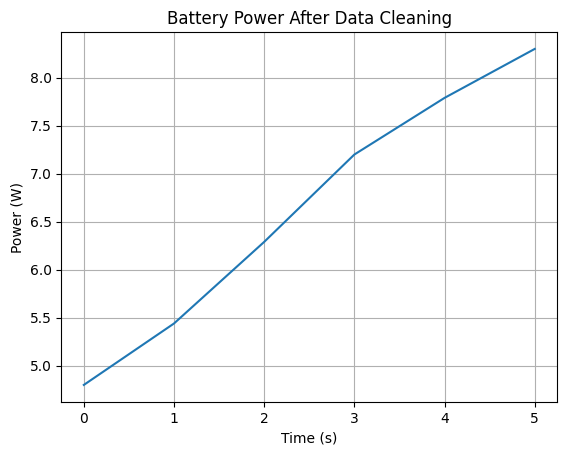

In [ ]:
plt.figure()
plt.plot(df_clean["time_s"], df_clean["power_W"])
plt.xlabel("Time (s)")
plt.ylabel("Power (W)")
plt.title("Battery Power After Data Cleaning")
plt.grid(True)
plt.show()
